In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import missingno as msno

ModuleNotFoundError: No module named 'missingno'

In [ ]:
data = pd.read_parquet(r"sale_and_crime_data\chicago_sales_with_crime.parquet")

In [121]:
data.shape

(56629, 85)

<Axes: >

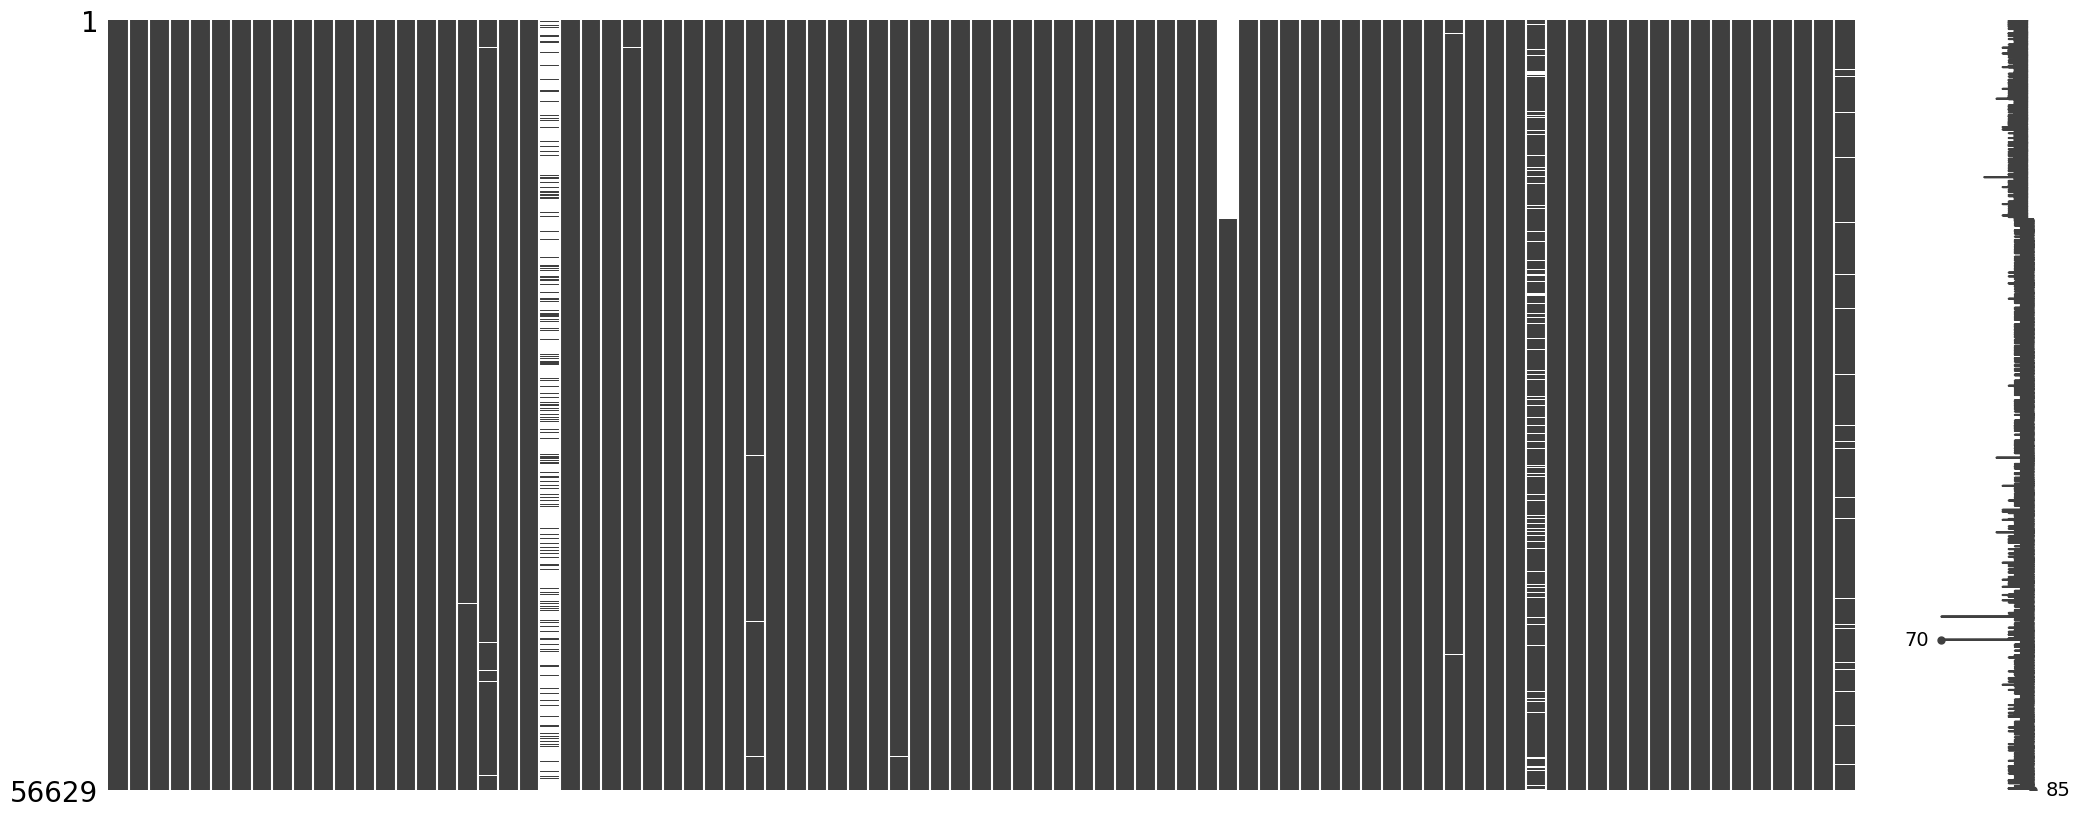

In [130]:
msno.matrix(data)

In [122]:
data.columns

Index(['pin', 'year', 'township_code', 'neighborhood_code', 'class',
       'sale_date', 'sale_price', 'is_multisale',
       'sale_filter_same_sale_within_365', 'sale_filter_less_than_10k',
       'sale_filter_deed_type', 'year_built', 'building_sqft', 'land_sqft',
       'num_bedrooms', 'num_rooms', 'num_full_baths', 'num_half_baths',
       'num_fireplaces', 'type_of_residence', 'construction_quality',
       'attic_finish', 'garage_size', 'basement_type', 'ext_wall_material',
       'central_heating', 'repair_condition', 'basement_finish',
       'single_v_multi_family', 'central_air', 'pin10', 'zip_code',
       'longitude', 'latitude', 'centroid_x_crs_3435', 'centroid_y_crs_3435',
       'community_area', 'flood_fema_sfha', 'flood_fs_factor',
       'airport_noise_dnl', 'school_elementary_district_name',
       'school_secondary_district_name', 'cmap_walkability_total_score',
       'census_acs5_tract_geoid', 'num_pin_in_half_mile',
       'num_bus_stop_in_half_mile',
       'num

NOTES: Attic Finish and Golf course distance were removed as they had a lot of missing values, missing values for Attic Finish are not seen in Noah's earlier work as it was turned into a categorical variable but the vast majority of rows had this attribute missing. Golf Course distance is responsible for about 13000 missing values so I thought I'd see what the effect of removing the column was, though it should be noted this did not change the general picture of coverage of community areas.

In [123]:
model_data = data.drop(columns = ["pin","is_multisale",'flood_fema_sfha', "sale_filter_same_sale_within_365", "sale_filter_less_than_10k", "single_v_multi_family", "zip_code",
                      "longitude", "latitude", "sale_date_parsed", "class", 'centroid_x_crs_3435', 'centroid_y_crs_3435', 'pin10', 'nearest_metra_route_dist_ft', 'nearest_new_construction_pin10',
                       "school_elementary_district_name",'nearest_golf_course_dist_ft', "school_secondary_district_name", "township_code",  "neighborhood_code",'sale_filter_deed_type', 'nearest_cta_route_dist_ft',
                                 'nearest_vacant_land_pin10','airport_noise_dnl','attic_finish','census_acs5_tract_geoid', 'nearest_neighbor_1_pin10','nearest_neighbor_2_pin10','nearest_neighbor_3_pin10','sale_date_parsed','sale_date', 'sale_year'])

In [124]:
model_data

,year,sale_price,year_built,building_sqft,land_sqft,num_bedrooms,num_rooms,num_full_baths,num_half_baths,num_fireplaces,...,nearest_road_highway_daily_traffic,nearest_secondary_road_dist_ft,nearest_stadium_dist_ft,nearest_university_dist_ft,nearest_vacant_land_dist_ft,nearest_water_dist_ft,nearest_neighbor_1_dist_ft,nearest_neighbor_2_dist_ft,nearest_neighbor_3_dist_ft,total_homicides_since_2020
0,2021,75750,1903.0,1212.0,3055.0,3.0,8.0,1.0,1.0,0.0,...,14000.0,236.614902,15538.440392,15195.847901,73.035853,6902.713322,24.435430,24.630775,48.740350,148.0
1,2021,300000,1893.0,2112.0,4450.0,4.0,6.0,2.0,0.0,0.0,...,8500.0,307.708987,25747.595652,27069.912063,62.502432,1727.407302,25.002793,37.510129,62.502432,264.0
2,2021,2310000,1898.0,2844.0,3800.0,5.0,9.0,3.0,0.0,0.0,...,8300.0,214.375406,13069.631187,5923.637009,712.421810,911.798432,26.160372,27.072215,53.623910,3.0
3,2021,222500,1952.0,840.0,3720.0,2.0,4.0,1.0,0.0,0.0,...,10000.0,748.617977,48520.703184,49848.561048,782.931038,2123.890206,29.956796,29.962776,59.923590,5.0
4,2021,1015000,2000.0,2675.0,2400.0,6.0,12.0,6.0,0.0,1.0,...,5800.0,744.866280,6339.956393,9003.011039,368.897548,4709.792693,24.010258,25.026153,48.011566,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56624,2025,410000,1957.0,1283.0,6250.0,3.0,6.0,1.0,1.0,0.0,...,2600.0,236.408960,30683.240165,32942.076265,2363.837457,10426.937773,43.741528,81.209872,105.146186,13.0
56625,2025,179900,1892.0,1450.0,3056.0,3.0,6.0,2.0,0.0,0.0,...,NaN,2045.879701,20434.069680,8662.278069,40.798423,5665.014498,24.451714,40.798423,53.024147,151.0
56626,2025,475000,1993.0,1913.0,1481.0,4.0,6.0,3.0,1.0,0.0,...,3700.0,472.676758,3802.614253,6940.639284,37.882384,602.383573,18.743776,22.717435,33.739741,15.0
56627,2025,300000,1888.0,940.0,3125.0,2.0,4.0,1.0,0.0,0.0,...,11400.0,445.575481,14538.649548,16611.916866,49.223549,2425.627526,24.956850,24.967138,49.223549,127.0


In [125]:
model_data.dtypes

year                                            int64
sale_price                                      int64
year_built                                    float64
building_sqft                                 float64
land_sqft                                     float64
num_bedrooms                                  float64
num_rooms                                     float64
num_full_baths                                float64
num_half_baths                                float64
num_fireplaces                                float64
type_of_residence                            category
construction_quality                         category
garage_size                                  category
basement_type                                category
ext_wall_material                            category
central_heating                                object
repair_condition                             category
basement_finish                              category
central_air                 

## Determining the effects of dropped values

We would like to drop all rows that are missing information of one of our variables but we need to make sure that this doesn't negatively affect the sampling of our community areas so we will build some histograms

(array([5456., 9052., 6422., 4538.,  814., 3798., 6731., 4209., 6641.,
        8968.]),
 array([ 1. ,  8.6, 16.2, 23.8, 31.4, 39. , 46.6, 54.2, 61.8, 69.4, 77. ]),
 <BarContainer object of 10 artists>)

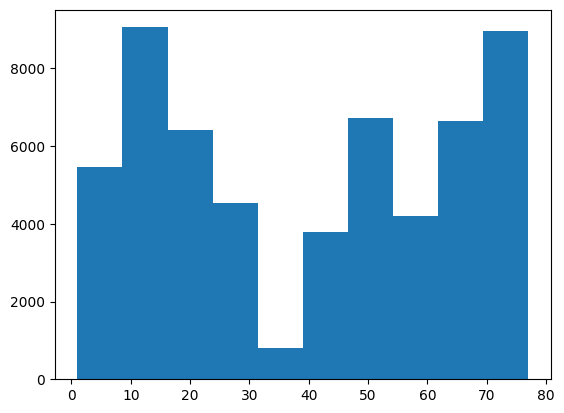

In [113]:
plt.hist(model_data["community_area"])

THE BELOW INFO KEPT GOLF COURSE

In [114]:
model_data=model_data.dropna()

In [115]:
model_data.shape

(36420, 54)

(array([3076., 5871., 4400., 3239.,  546., 1854., 4436., 2451., 4721.,
        5826.]),
 array([ 1. ,  8.6, 16.2, 23.8, 31.4, 39. , 46.6, 54.2, 61.8, 69.4, 77. ]),
 <BarContainer object of 10 artists>)

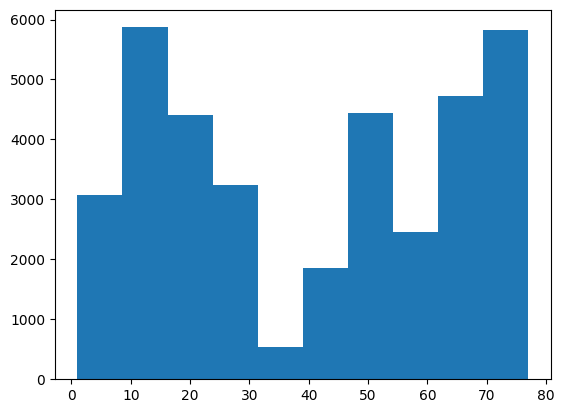

In [118]:
plt.hist(model_data["community_area"])

In [117]:
num_dropped_rows_keeping_golf_course = np.array([5456., 9052., 6422., 4538.,  814., 3798., 6731., 4209., 6641.,8968.]) - np.array([3076., 5871., 4400., 3239.,  546., 1854., 4436., 2451., 4721.,
        5826.])
print(num_dropped_rows_keeping_golf_course)

[2380. 3181. 2022. 1299.  268. 1944. 2295. 1758. 1920. 3142.]


THE BELOW HAS GOLF COURSE DISTANCE REMOVED

In [127]:
model_data = model_data.dropna()
model_data.shape

(49230, 53)

(array([4333., 8064., 6080., 4395.,  783., 2447., 5751., 3382., 6228.,
        7767.]),
 array([ 1. ,  8.6, 16.2, 23.8, 31.4, 39. , 46.6, 54.2, 61.8, 69.4, 77. ]),
 <BarContainer object of 10 artists>)

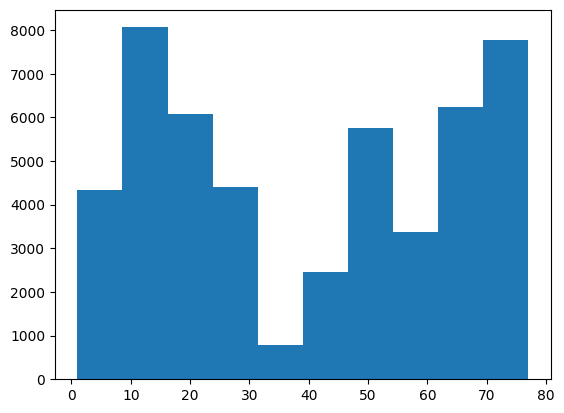

In [131]:
plt.hist(model_data["community_area"])

In [132]:
num_dropped_rows = np.array([5456., 9052., 6422., 4538.,  814., 3798., 6731., 4209., 6641.,8968.])-np.array([4333., 8064., 6080., 4395.,  783., 2447., 5751., 3382., 6228.,7767.])
print(num_dropped_rows)

[1123.  988.  342.  143.   31. 1351.  980.  827.  413. 1201.]


These results suggest that the coverage of community areas remains more or less the same after dropping missing values and there is no systematic loss of one community area over another regardless of what info is kept, though removing the golf course feature does keep an extra 13000 datapoints.

## One Hot Encoding Categorical Features

In [133]:
categorical_features = ["type_of_residence", "construction_quality", "garage_size", "basement_type", "ext_wall_material", "central_heating",
                       'repair_condition', 'basement_finish', 'central_air', 'year','community_area']

In [134]:
model_data = pd.get_dummies(model_data, columns = categorical_features, dtype=int)

In [135]:
model_data

,sale_price,year_built,building_sqft,land_sqft,num_bedrooms,num_rooms,num_full_baths,num_half_baths,num_fireplaces,flood_fs_factor,...,community_area_67,community_area_68,community_area_69,community_area_70,community_area_71,community_area_72,community_area_73,community_area_75,community_area_76,community_area_77
0,75750,1903.0,1212.0,3055.0,3.0,8.0,1.0,1.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
1,300000,1893.0,2112.0,4450.0,4.0,6.0,2.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
2,2310000,1898.0,2844.0,3800.0,5.0,9.0,3.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
3,222500,1952.0,840.0,3720.0,2.0,4.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
4,1015000,2000.0,2675.0,2400.0,6.0,12.0,6.0,0.0,1.0,3.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56621,2500000,2025.0,3278.0,3720.0,6.0,11.0,4.0,1.0,2.0,1.0,...,0,0,0,0,0,0,0,0,0,0
56622,360000,1911.0,933.0,4125.0,2.0,5.0,1.0,1.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
56624,410000,1957.0,1283.0,6250.0,3.0,6.0,1.0,1.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
56626,475000,1993.0,1913.0,1481.0,4.0,6.0,3.0,1.0,0.0,4.0,...,0,0,0,0,0,0,0,0,0,0


In [136]:
model_data.columns

Index(['sale_price', 'year_built', 'building_sqft', 'land_sqft',
       'num_bedrooms', 'num_rooms', 'num_full_baths', 'num_half_baths',
       'num_fireplaces', 'flood_fs_factor',
       ...
       'community_area_67', 'community_area_68', 'community_area_69',
       'community_area_70', 'community_area_71', 'community_area_72',
       'community_area_73', 'community_area_75', 'community_area_76',
       'community_area_77'],
      dtype='object', length=157)

## Building Models

We will use this data to build a variety of ridge regression models (not lasso as we want to ensure none of our community area features are zeroed out), see which gives the best R^2 value and then pull the coefficients of the best model to get an estimate of the community factor on a home in terms of how much it adds to the sale price of the home.

In [138]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate

In [140]:
y = model_data["sale_price"]
features = list(model_data.columns)
features.remove("sale_price")
X = model_data[features]

In [145]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55)

In [150]:
# 1. Build a pipeline: scale features, then fit Ridge
pipeline1 = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0, random_state=56))
])

# 2. Set up cross-validation splitting strategy
cv = KFold(n_splits=5, shuffle=True, random_state=75)

# 3. Run cross-validation with multiple scoring metrics
scoring = {
    "r2": "r2",
    "neg_mae": "neg_mean_absolute_error",
    "neg_rmse": "neg_root_mean_squared_error"
}

results = cross_validate(
    pipeline1, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# 4. Summarize results
print(results["test_r2"])
print("R²:    mean = {:.4f}, std = {:.4f}".format(
    results["test_r2"].mean(), results["test_r2"].std()))
print("MAE:   mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_mae"].mean(), results["test_neg_mae"].std()))
print("RMSE:  mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_rmse"].mean(), results["test_neg_rmse"].std()))

# Optional: compare to train scores to check for overfitting
print("\nTrain R² (for comparison): {:.4f}".format(results["train_r2"].mean()))

[0.80286719 0.8077718  0.76931162 0.78374019 0.78389007]
R²:    mean = 0.7895, std = 0.0140
MAE:   mean = 127515.1755, std = 1274.3269
RMSE:  mean = 215116.7034, std = 12122.6954

Train R² (for comparison): 0.7920


In [151]:
# 1. Build a pipeline: scale features, then fit Ridge
pipeline2 = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0, random_state=56))
])

# 2. Set up cross-validation splitting strategy
cv = KFold(n_splits=5, shuffle=True, random_state=75)

# 3. Run cross-validation with multiple scoring metrics
scoring = {
    "r2": "r2",
    "neg_mae": "neg_mean_absolute_error",
    "neg_rmse": "neg_root_mean_squared_error"
}

results = cross_validate(
    pipeline2, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# 4. Summarize results
print(results["test_r2"])
print("R²:    mean = {:.4f}, std = {:.4f}".format(
    results["test_r2"].mean(), results["test_r2"].std()))
print("MAE:   mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_mae"].mean(), results["test_neg_mae"].std()))
print("RMSE:  mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_rmse"].mean(), results["test_neg_rmse"].std()))

# Optional: compare to train scores to check for overfitting
print("\nTrain R² (for comparison): {:.4f}".format(results["train_r2"].mean()))

[0.80290339 0.80777065 0.7692796  0.78374136 0.78390148]
R²:    mean = 0.7895, std = 0.0140
MAE:   mean = 127487.1457, std = 1276.8062
RMSE:  mean = 215115.0566, std = 12130.9376

Train R² (for comparison): 0.7920


In [152]:
# 1. Build a pipeline: scale features, then fit Ridge
pipeline3 = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=0.1, random_state=56))
])

# 2. Set up cross-validation splitting strategy
cv = KFold(n_splits=5, shuffle=True, random_state=75)

# 3. Run cross-validation with multiple scoring metrics
scoring = {
    "r2": "r2",
    "neg_mae": "neg_mean_absolute_error",
    "neg_rmse": "neg_root_mean_squared_error"
}

results = cross_validate(
    pipeline3, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# 4. Summarize results
print(results["test_r2"])
print("R²:    mean = {:.4f}, std = {:.4f}".format(
    results["test_r2"].mean(), results["test_r2"].std()))
print("MAE:   mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_mae"].mean(), results["test_neg_mae"].std()))
print("RMSE:  mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_rmse"].mean(), results["test_neg_rmse"].std()))

# Optional: compare to train scores to check for overfitting
print("\nTrain R² (for comparison): {:.4f}".format(results["train_r2"].mean()))

[0.80286347 0.80777184 0.76931479 0.78374003 0.78388887]
R²:    mean = 0.7895, std = 0.0140
MAE:   mean = 127518.0428, std = 1274.0734
RMSE:  mean = 215116.9002, std = 12121.8607

Train R² (for comparison): 0.7920


Little observed difference when changing the alpha of the ridge regression, overall train R^2 comparable to previous work, standard deviations are a bit smaller across the three metrics, mean is slightly smaller for MAE and RMSE and slightly higher for R^2.

The initial idea was to evaluate which of these methods gave the best results and just evaluate that one on the whole data or the test data to see, but as these models perform more or less the same, we will just fit these pipelines on the whole dataset and see

In [153]:
results = cross_validate(
    pipeline1, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# 4. Summarize results
print(results["test_r2"])
print("R²:    mean = {:.4f}, std = {:.4f}".format(
    results["test_r2"].mean(), results["test_r2"].std()))
print("MAE:   mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_mae"].mean(), results["test_neg_mae"].std()))
print("RMSE:  mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_rmse"].mean(), results["test_neg_rmse"].std()))

# Optional: compare to train scores to check for overfitting
print("\nTrain R² (for comparison): {:.4f}".format(results["train_r2"].mean()))

[0.77828084 0.77793187 0.79088239 0.79711112 0.78920874]
R²:    mean = 0.7867, std = 0.0075
MAE:   mean = 128056.2852, std = 1432.8410
RMSE:  mean = 217297.4753, std = 8200.2620

Train R² (for comparison): 0.7893


In [154]:
results = cross_validate(
    pipeline2, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# 4. Summarize results
print(results["test_r2"])
print("R²:    mean = {:.4f}, std = {:.4f}".format(
    results["test_r2"].mean(), results["test_r2"].std()))
print("MAE:   mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_mae"].mean(), results["test_neg_mae"].std()))
print("RMSE:  mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_rmse"].mean(), results["test_neg_rmse"].std()))

# Optional: compare to train scores to check for overfitting
print("\nTrain R² (for comparison): {:.4f}".format(results["train_r2"].mean()))

[0.77827328 0.77790464 0.79090121 0.79712067 0.78922688]
R²:    mean = 0.7867, std = 0.0075
MAE:   mean = 128033.7723, std = 1430.9587
RMSE:  mean = 217296.3428, std = 8208.5416

Train R² (for comparison): 0.7893


In [155]:
results = cross_validate(
    pipeline3, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# 4. Summarize results
print(results["test_r2"])
print("R²:    mean = {:.4f}, std = {:.4f}".format(
    results["test_r2"].mean(), results["test_r2"].std()))
print("MAE:   mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_mae"].mean(), results["test_neg_mae"].std()))
print("RMSE:  mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_rmse"].mean(), results["test_neg_rmse"].std()))

# Optional: compare to train scores to check for overfitting
print("\nTrain R² (for comparison): {:.4f}".format(results["train_r2"].mean()))

[0.77828157 0.77793457 0.79088046 0.79711011 0.78920688]
R²:    mean = 0.7867, std = 0.0075
MAE:   mean = 128058.5724, std = 1433.0337
RMSE:  mean = 217297.6084, std = 8199.4303

Train R² (for comparison): 0.7893


In [156]:
# Fit the pipeline on the entire training data
pipeline1.fit(X, y)

# Extract the fitted Ridge model and coefficients
ridge_model = pipeline1.named_steps["ridge"]
coefficients = ridge_model.coef_
intercept = ridge_model.intercept_

# Put coefficients into a readable dataframe, sorted by magnitude
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coefficients
}).sort_values(by="coefficient", key=abs, ascending=False)

print("Intercept:", intercept)
print("\nCoefficients (sorted by absolute magnitude):")
print(coef_df.to_string(index=False))

Intercept: 427695.0458460288

Coefficients (sorted by absolute magnitude):
                                  feature   coefficient
                            building_sqft 222205.853848
                         community_area_7 108694.282236
                    lake_michigan_dist_ft -61407.210150
                        community_area_24  56804.379090
                         community_area_6  52178.666974
                         community_area_8  51398.030613
                           num_full_baths  51328.694979
                         community_area_5  48744.813882
                        community_area_22  46652.722414
num_foreclosure_in_half_mile_past_5_years -46578.297386
num_foreclosure_per_1000_pin_past_5_years  46339.965786
               total_homicides_since_2020 -44699.994623
                type_of_residence_1 Story  42651.759229
                                land_sqft  30827.737647
                        community_area_49 -30473.561478
                        commu

In [157]:
community_coef_df = coef_df[coef_df["feature"].str.startswith("community_area_")]

print(community_coef_df.to_string(index=False))

          feature   coefficient
 community_area_7 108694.282236
community_area_24  56804.379090
 community_area_6  52178.666974
 community_area_8  51398.030613
 community_area_5  48744.813882
community_area_22  46652.722414
community_area_49 -30473.561478
community_area_44 -28861.603725
community_area_53 -28513.948794
community_area_69 -28401.423765
community_area_48 -27697.811292
community_area_45 -25821.073998
community_area_73 -25334.552621
community_area_46 -24280.321162
community_area_70 -23716.133799
community_area_71 -21158.611588
community_area_72 -20646.429697
community_area_38 -19878.231430
community_area_68 -19193.934272
community_area_75 -19097.931402
community_area_50 -18967.055417
community_area_51 -18519.414779
community_area_67 -18144.016893
 community_area_4  17733.220833
community_area_28  17117.305476
community_area_47 -16589.755951
community_area_25  15976.125664
community_area_42 -13943.882355
community_area_66 -13890.573898
community_area_33  13570.698799
communit

In [158]:
# Fit the pipeline on the entire training data
pipeline2.fit(X, y)

# Extract the fitted Ridge model and coefficients
ridge_model = pipeline1.named_steps["ridge"]
coefficients = ridge_model.coef_
intercept = ridge_model.intercept_

# Put coefficients into a readable dataframe, sorted by magnitude
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coefficients
}).sort_values(by="coefficient", key=abs, ascending=False)

print("Intercept:", intercept)
print("\nCoefficients (sorted by absolute magnitude):")
print(coef_df.to_string(index=False))

Intercept: 427695.0458460288

Coefficients (sorted by absolute magnitude):
                                  feature   coefficient
                            building_sqft 222205.853848
                         community_area_7 108694.282236
                    lake_michigan_dist_ft -61407.210150
                        community_area_24  56804.379090
                         community_area_6  52178.666974
                         community_area_8  51398.030613
                           num_full_baths  51328.694979
                         community_area_5  48744.813882
                        community_area_22  46652.722414
num_foreclosure_in_half_mile_past_5_years -46578.297386
num_foreclosure_per_1000_pin_past_5_years  46339.965786
               total_homicides_since_2020 -44699.994623
                type_of_residence_1 Story  42651.759229
                                land_sqft  30827.737647
                        community_area_49 -30473.561478
                        commu

In [159]:
community_coef_df = coef_df[coef_df["feature"].str.startswith("community_area_")]

print(community_coef_df.to_string(index=False))

          feature   coefficient
 community_area_7 108694.282236
community_area_24  56804.379090
 community_area_6  52178.666974
 community_area_8  51398.030613
 community_area_5  48744.813882
community_area_22  46652.722414
community_area_49 -30473.561478
community_area_44 -28861.603725
community_area_53 -28513.948794
community_area_69 -28401.423765
community_area_48 -27697.811292
community_area_45 -25821.073998
community_area_73 -25334.552621
community_area_46 -24280.321162
community_area_70 -23716.133799
community_area_71 -21158.611588
community_area_72 -20646.429697
community_area_38 -19878.231430
community_area_68 -19193.934272
community_area_75 -19097.931402
community_area_50 -18967.055417
community_area_51 -18519.414779
community_area_67 -18144.016893
 community_area_4  17733.220833
community_area_28  17117.305476
community_area_47 -16589.755951
community_area_25  15976.125664
community_area_42 -13943.882355
community_area_66 -13890.573898
community_area_33  13570.698799
communit

In [160]:
# Fit the pipeline on the entire training data
pipeline3.fit(X, y)

# Extract the fitted Ridge model and coefficients
ridge_model = pipeline1.named_steps["ridge"]
coefficients = ridge_model.coef_
intercept = ridge_model.intercept_

# Put coefficients into a readable dataframe, sorted by magnitude
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coefficients
}).sort_values(by="coefficient", key=abs, ascending=False)

print("Intercept:", intercept)
print("\nCoefficients (sorted by absolute magnitude):")
print(coef_df.to_string(index=False))

Intercept: 427695.0458460288

Coefficients (sorted by absolute magnitude):
                                  feature   coefficient
                            building_sqft 222205.853848
                         community_area_7 108694.282236
                    lake_michigan_dist_ft -61407.210150
                        community_area_24  56804.379090
                         community_area_6  52178.666974
                         community_area_8  51398.030613
                           num_full_baths  51328.694979
                         community_area_5  48744.813882
                        community_area_22  46652.722414
num_foreclosure_in_half_mile_past_5_years -46578.297386
num_foreclosure_per_1000_pin_past_5_years  46339.965786
               total_homicides_since_2020 -44699.994623
                type_of_residence_1 Story  42651.759229
                                land_sqft  30827.737647
                        community_area_49 -30473.561478
                        commu

In [161]:
community_coef_df = coef_df[coef_df["feature"].str.startswith("community_area_")]

print(community_coef_df.to_string(index=False))

          feature   coefficient
 community_area_7 108694.282236
community_area_24  56804.379090
 community_area_6  52178.666974
 community_area_8  51398.030613
 community_area_5  48744.813882
community_area_22  46652.722414
community_area_49 -30473.561478
community_area_44 -28861.603725
community_area_53 -28513.948794
community_area_69 -28401.423765
community_area_48 -27697.811292
community_area_45 -25821.073998
community_area_73 -25334.552621
community_area_46 -24280.321162
community_area_70 -23716.133799
community_area_71 -21158.611588
community_area_72 -20646.429697
community_area_38 -19878.231430
community_area_68 -19193.934272
community_area_75 -19097.931402
community_area_50 -18967.055417
community_area_51 -18519.414779
community_area_67 -18144.016893
 community_area_4  17733.220833
community_area_28  17117.305476
community_area_47 -16589.755951
community_area_25  15976.125664
community_area_42 -13943.882355
community_area_66 -13890.573898
community_area_33  13570.698799
communit

Here we see that there is essentially no effect of changing the alpha by an order of magnitude either way. Given the arbitrariness, we may as well keep the alpha = 1 results. 

We can also see that these results are similar to those found previously up to a few thousand. Suggesting the general trend of the effect of neighborhoods is captured by both of these models. I will build some Choropleth maps for these two coefficients soon.